In [61]:
import pandas as pd 
import xarray as xr


ds = xr.open_dataset("test_sediment.nc", decode_timedelta=False)
print(ds)

nt = ds.dims['t']
eid = ds.dims['eid']
print(eid)
print(nt)

<xarray.Dataset> Size: 173MB
Dimensions:       (t: 360, eid: 500, z: 60)
Coordinates:
  * z             (z) float32 240B 5.95 5.85 5.75 5.65 ... 0.35 0.25 0.15 0.05
  * t             (t) int64 3kB 1 2 3 4 5 6 7 8 ... 354 355 356 357 358 359 360
  * eid           (eid) int64 4kB 1 2 3 4 5 6 7 ... 494 495 496 497 498 499 500
Data variables:
    observations  (t) float64 3kB ...
    floc1         (eid, t, z) float64 86MB ...
    floc2         (eid, t, z) float64 86MB ...
500
360


/tmp/ipykernel_1632733/159865447.py:8: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  nt = ds.dims['t']
/tmp/ipykernel_1632733/159865447.py:9: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  eid = ds.dims['eid']


<xarray.DataArray 'floc1' (z: 60)> Size: 480B
array([182.04526793, 178.59564089, 180.47439741, 181.55168985,
       178.48115009, 175.78853952, 179.64247803, 181.57619855,
       184.56407776, 183.01859087, 176.83094085, 179.81520237,
       177.47211821, 178.36431134, 181.4804511 , 177.48675202,
       182.73433871, 180.86256918, 182.63601517, 178.24958995,
       176.45147755, 179.09513524, 178.88439878, 177.49166087,
       180.30589982, 182.39913844, 177.95498684, 179.32792365,
       175.63919973, 175.60032189, 179.37939366, 176.79035433,
       179.64195961, 181.66060117, 182.68930931, 183.64246488,
       179.25264504, 177.67446891, 183.07390487, 178.22553478,
       182.1799283 , 176.67454333, 179.537115  , 180.81596251,
       181.54729445, 175.19803957, 177.01271377, 179.11112508,
       176.9218311 , 179.11015092, 178.7148145 , 180.28744667,
       184.23887298, 180.9820808 , 183.20211425, 178.55650103,
       180.5060317 , 182.03067208, 183.03151341, 177.65011551])
Coordina

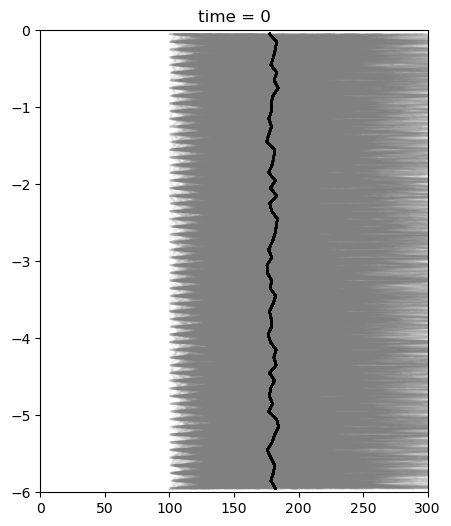

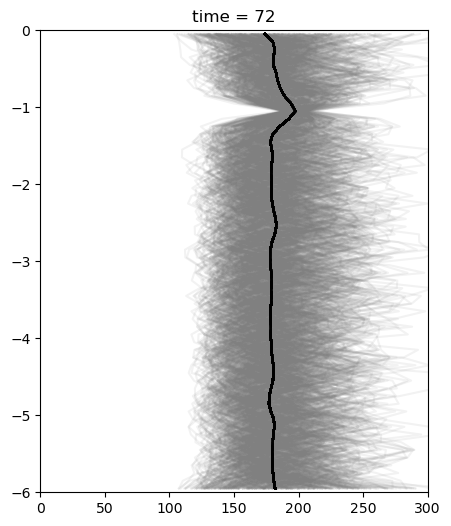

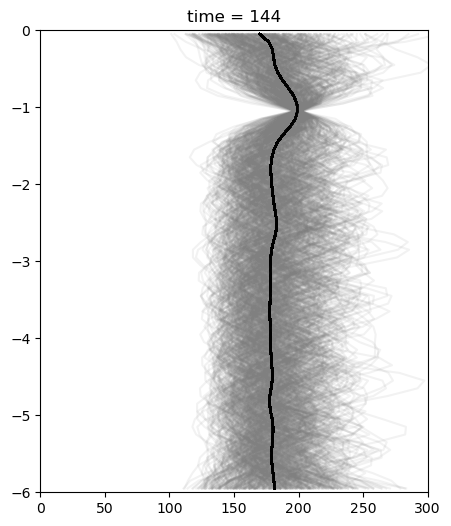

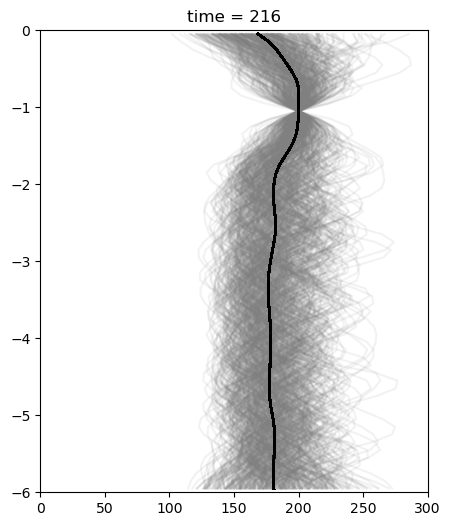

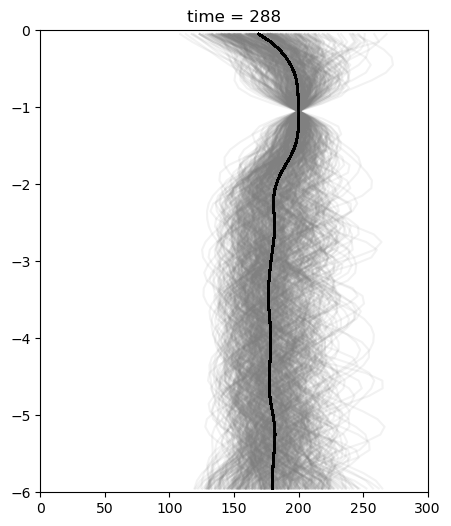

In [ ]:
import matplotlib.pyplot as plt 

z = ds['z'].values
t = ds['t'].values

for TIME in range(0, nt, nt//5):
    fig = plt.figure(figsize=(5,6))
    ax=plt.gca() 
    for eid in range(0,eid):
        plt.plot(ds['floc1'].isel(t=TIME).isel(eid=eid), -ds['z'], color="gray", alpha=0.1)
        average1 = ds['floc1'].isel(t=TIME).mean(dim='eid') 
        plt.plot(average1, -ds['z'], color="k", alpha=0.8)

    # plt.legend()
    ax.set_title("time = %d" % TIME)

    ax.set_xlim(0, 300)
    ax.set_ylim(-6, 0)

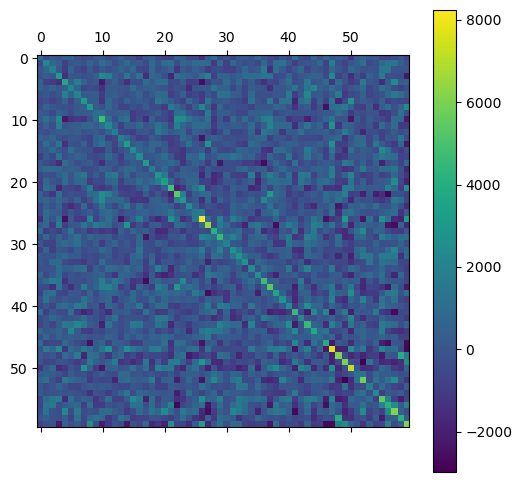

In [43]:
# 
import numpy as np 

cov = np.cov(ds['floc1'].isel(t=2).values.T)

# Plot covariance matrix
fig = plt.figure(figsize=(6,6))
ax = plt.gca()
cax = ax.matshow(cov, cmap='viridis')
fig.colorbar(cax)

# Particle Exchange model

$ \frac{dn_k}{dt} = G_1(k) + G_2(k) + G_3(k) - L_1(k) - L_2(k) - L_3(k)$ 

Here, the terms are related as:
1. Aggregation
2. Breakup due to shear
3. Breakup due to collision 

Note that each process can serve as both a loss and a gain to that particle class. 

# Aggregation 
Two-body collision probability function A(i,j) is a function of the shear rate G and the particle diameters $D_i$ and $D_j$

$ G_1(k) = \frac{1}{2} \sum_{i+j=k} \alpha_{ij} A(i,j) n_i n_j$ 

And loss is given by,

$ L_1(k) =  \sum_{i=1}^n \alpha_{ik} A(i,k) n_i n_k$

A(i,j) is given by

$ A(i,j) = \frac{1}{6} G (D_i + D_j)^3 $ 

# Shear break-up 
These terms represent the gain and loss of k-class particles
from the fragmentation of larger flocs (iZk) induced by the
turbulent shear stress. The probability of a k-class floc to breakup
for a given G value is expressed by the fragmentation probability
function Bi as proposed by (Winterwerp, 2002)

$G_2(k) =  \sum_{i= k+1}^n FDBS_{ki} n_i $

$L_2(k) = B_k n_k $ 

$ B_i = \beta_i G^{\beta_2} D_i \left( \frac{D_i - D_p}{D_p} \right)^{\beta_3}

note that $\beta$ is the fragmentation rate, as a function of floc yield strength .. 

$ \beta_2 = 3/2 $ 

and 

$\beta_3 = 3 - n_f $ 

$FDBS_{ki}$ is the distribution function of fragmented flocs for shear breakup. It's a source of large uncertainty and there's three options to pick and choose from. Simplest is 

$ FDBS_{ij} = 2 $ if $m_j = m_i/2$  
otherwise, $ FDBS_{ij} = 0 $

# Collision-induced breakup 
If the collision-induced shear stress is greater than the strength of the particles, then the collision will cause breakup instead of aggregation. 

$ G_3 (k) = \sum_{i,j} FDBC_{ij} A(i,j) n_i n_j $ 

$ L_3 (k) = \sum_{i=1}^N FDBC_{ik} A(i,k) n_i n_k $  

A is the same as defined earlier. FDBC is a distribution function that looks at whether or not the collision-induced stress exceeds the strength of the particles. 

We calculate the  collision-induced stress for floc i colliding with floc j is given by 

$ T_{ij, i}^c = \frac{8 \left(G(D_i + D_j)/2)\right)^2 m_i m_j}{\pi F_p D_i^2 (D_i + D_j)(m_i + m_j)}$

And floc strength is estimated from floc density, 

$ T_{y,i} = F_y \left(  \frac{\Delta \rho_i}{rho} \right)^{2/(3-n_f)}$ 

Fp represents the relative depth of interparticle penetration and is estimated to be 0.1
F_y is the yield strength ... very empirical and usually assumed to be order 1e-10. 

w_s = 

In [44]:
import numpy as np

g = 9.81  # m/s^2
nu = 1.3e-6  # m^2/s
rho_w = 1000  # kg/m^3


D = 100e-6
def w_s(rho_s, D):
    return g/(18*nu) * (rho_s - rho_w)/(rho_w) * D**2 


alpha = 1 

N = 10  # number of size classes
n = np.zeros(N) + 100 

D = np.logspace(-6, -3, N)  # particle diameters from 1 micron to 1 mm

G = 1e-3  # shear rate

def A(i,j):
    # Two-body collision probability function A(i,j) is a function of the 
    # shear rate G and the particle diameters $D_i$ and $D_j$
    return 1/6 * G * (D[i] + D[j])**3

def g1(k):
    # Growth due to collisions for class k 
    g1_ = 0 
    for i in range(1, k):
        j = k - i
        print(f"i={i}, j={j}")
        g1_ += alpha * A(i,j) * n[i] * n[j]
    g1_ *= 0.5
    return g1_

def l1(k):
    # Loss due to collisions for class k
    l1_ = 0 
    for i in range(1, N):
        l1_ += alpha * A(i,k) * n[i] * n[k]
    return l1_


rho_s = 2650  # kg/m^3

Dp = 200e-6  # reference diameter
nf = 0.5  # fractal dimension exponent

def mass(i):
    mass_ = rho_s * np.pi/6 * D[i]**3 * (D[i]/Dp)**nf 
    return mass_

def g2(k):
    g2_ = 0
    for i in range(k+1, N):
        g2_ += FDBS(k,i) * n[i]
    return g2_

def l2(k):
    l2_ = B(k) * n[k]
    return l2_

beta = 0.1 


def B(i):
    Bi = beta * G**(3/2) * D[i] * ((D[i] - Dp)/Dp)**(3-nf)

def FDBS(i,j):
    if mass(j) == mass(i)/2:    
        FDBS_ = 2
    else: 
        FDBS_ = 0
    return FDBS_

def g3(k):
    g3_ = 0
    for i in range(1, N):
        for j in range(1, N):
            g3_ += FDBC(i,j) * A(i,j) * n[i] * n[j]
    return g3_

def l3(k):
    l3_ = 0
    for i in range(1, N):
        l3_ += FDBC(i,k) * A(i,k) * n[i] * n[k]
    return l3_


def FDBC(i,k):
    tau_c = tau_collision(i,k)
    tau_s = tau_floc_strength(i)

Fp = 0.1 
def tau_collision(i,j):
    # collision-induced stress for floc i colliding with floc j
    T_c = 8 * ((G * (D[i] + D[j])/2)**2 * mass(i) * mass(j))/(np.pi * Fp * D[i]**2 * (D[i] + D[j]) * (mass(i) + mass(j)))
    return T_c

def tau_floc_strength(i):
    Fy = 1e-10 # yield strength
    tau_s = Fy * ((rho_s - rho_w)/rho_w)**(2/(3 - nf))
#  FDBC is a distribution function that looks at whether or not the collision-induced stress exceeds the strength of the particles. 

print(tau_collision(1,9))


1.979448804343696e-12


In [45]:
# Shear break-up 
These terms represent the gain and loss of k-class particles
from the fragmentation of larger flocs (iZk) induced by the
turbulent shear stress. The probability of a k-class floc to breakup
for a given G value is expressed by the fragmentation probability
function Bi as proposed by (Winterwerp, 2002)

$G_2(k) =  \sum_{i= k+1}^n FDBS_{ki} n_i $

$L_2(k) = B_k n_k $ 

$ B_i = \beta_i G^{\beta_2} D_i \left( \frac{D_i - D_p}{D_p} \right)^{\beta_3}

note that $\beta$ is the fragmentation rate, as a function of floc yield strength .. 

$ \beta_2 = 3/2 $ 

and 

$\beta_3 = 3 - n_f $ 

$FDBS_{ki}$ is the distribution function of fragmented flocs for shear breakup. It's a source of large uncertainty and there's three options to pick and choose from. Simplest is 

$ FDBS_{ij} = 2 $ if $m_j = m_i/2$  
otherwise, $ FDBS_{ij} = 0 $

SyntaxError: invalid syntax (4226185062.py, line 2)

In [ ]:
# and the main floc characteristic sizes in each class i 
# (diameter Di, mass mi and density rf,i) can be expressed via the fractal dimension nf
# mass = rho_s * pi/6 * d50^3 * (Di/Dp)^nf 

# rho_fi = rho + (rho_s - rho) * (Di/Dp)^(nf - 3)
# source_aggregation = 1/2  alpha(i,j) * A(i,j) * n(i) * n(j)
# loss_aggregation(k) = alpha(i,k) * A(i,k) * n(i) * n(k)
# A(i,j)= 1/6 * G * (Di + Dj)^3
# alpha represents particle cohesiveness.. set as a constnat / used for calibration